# Phase 3 Step 4 — 종합 비교 + 학술 결론 (`04_compare_stockwise_vs_cross.ipynb`)

> **목적**: 종목별 (02a) vs Cross-Sectional (02b) 예측 정확도 + 포트폴리오 성과를
>          통합 비교하여 "어떤 방식이 더 우월한가?" 에 답한다.
>          Phase 3 의 최종 학술 결론 도출.

## 핵심 질문 3 가지

1. **예측 정확도**: CS 방식이 종목별보다 RMSE 에서 우위인가?
2. **포트폴리오 성과**: CS 기반 BL 이 종목별 BL 보다 Sharpe/MDD 에서 우위인가?
3. **서윤범 BL 비교**: Phase 3 의 ML 통합이 서윤범 baseline 을 능가하는가?

## 비교 방법론

| 비교 | 검정 방법 |
|---|---|
| RMSE 비교 (02a vs 02b) | Paired t-test + Wilcoxon |
| Sharpe 비교 | Jobson-Korkie test + Block Bootstrap |
| 시기별 분해 | 3 시기 × 6 시나리오 |

## 셀 구성

| § | 내용 |
|---|---|
| §1 | 환경 + 결과 로드 |
| §2 | RMSE 비교 (종목별 vs CS) |
| §3 | 포트폴리오 성과 비교 |
| §4 | Bootstrap 신뢰구간 |
| §5 | 시기별 분해 시각화 |
| §6 | 학술 결론 종합 |


## §1. 환경 부트스트랩 + 결과 로드

In [6]:
%load_ext autoreload
%autoreload 2

import sys, warnings
warnings.filterwarnings('ignore')
from pathlib import Path

NB_DIR = Path.cwd()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from scripts.setup import bootstrap, DATA_DIR, OUTPUTS_DIR

font_used = bootstrap()

OUT_DIR = OUTPUTS_DIR / '04_v2_compare'  # Phase 3-2 v2
OUT_DIR.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
  Phase 3 Robust Extensions — 환경 부트스트랩 완료
  한글 폰트   : Malgun Gothic
  시드        : 42
  데이터 경로  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\data
  Phase 1.5  : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase1_5_Volatility
  Phase 2    : C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase2_BL_Integration


In [7]:
# 결과 로드
OUT_BL = OUTPUTS_DIR / '03_bl_backtest'

# ensemble predictions
ens_sw = pd.read_csv(DATA_DIR / 'ensemble_predictions_stockwise.csv', parse_dates=['date'])
ens_cs = pd.read_csv(DATA_DIR / 'ensemble_predictions_crosssec.csv', parse_dates=['date'])

# portfolio returns
import json, os

def load_returns(scenario):
    path = OUT_BL / f'returns_{scenario}.csv'
    if path.exists():
        return pd.read_csv(path, index_col=0, parse_dates=True).squeeze()
    return None

scenarios = ['BL_ml_sw', 'BL_ml_cs', 'BL_trailing', 'EqualWeight', 'McapWeight', 'SPY']
portfolio_returns = {s: load_returns(s) for s in scenarios}
portfolio_returns = {s: r for s, r in portfolio_returns.items() if r is not None}

print(f'ensemble_sw: {ens_sw.shape}')
print(f'ensemble_cs: {ens_cs.shape}')
print(f'portfolio_returns: {list(portfolio_returns.keys())}')
for s, r in portfolio_returns.items():
    print(f'  {s}: {len(r)} 개월')

ensemble_sw: (2468883, 9)
ensemble_cs: (2635610, 9)
portfolio_returns: ['BL_ml_cs', 'EqualWeight', 'McapWeight', 'SPY']
  BL_ml_cs: 192 개월
  EqualWeight: 192 개월
  McapWeight: 192 개월
  SPY: 191 개월


## §2. RMSE 비교 (종목별 vs Cross-Sectional)

- **귀무가설 (H0)**: 두 방식의 RMSE 에 차이 없음
- **대립가설 (H1)**: CS 방식이 더 낮은 RMSE (단측)


In [8]:
def rmse(y_true, y_pred):
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    return np.sqrt(np.mean((y_true[mask] - y_pred[mask])**2)) if mask.sum() > 0 else np.nan

# 공통 종목 기준
common_tickers = set(ens_sw['ticker'].unique()) & set(ens_cs['ticker'].unique())
print(f'공통 종목 수: {len(common_tickers)}')

sw_pred_col = 'y_pred_ensemble'
cs_pred_col = 'y_pred_ensemble' if 'y_pred_ensemble' in ens_cs.columns else 'y_pred_lstm_cs'

# 종목별 RMSE
sw_rmse = {}
cs_rmse = {}
for t in common_tickers:
    sw_t = ens_sw[ens_sw['ticker'] == t]
    cs_t = ens_cs[ens_cs['ticker'] == t]
    sw_rmse[t] = rmse(sw_t['y_true'].values, sw_t[sw_pred_col].values)
    cs_rmse[t] = rmse(cs_t['y_true'].values, cs_t[cs_pred_col].values)

rmse_df = pd.DataFrame({'rmse_sw': sw_rmse, 'rmse_cs': cs_rmse}).replace([np.inf, -np.inf], np.nan).dropna()
print(f'\n평균 RMSE:')
print(f'  종목별 (02a): {rmse_df["rmse_sw"].mean():.4f}')
print(f'  Cross-Sec (02b): {rmse_df["rmse_cs"].mean():.4f}')

cs_better = (rmse_df['rmse_cs'] < rmse_df['rmse_sw']).sum()
print(f'\nCS 가 더 좋은 종목: {cs_better}/{len(rmse_df)} ({cs_better/len(rmse_df)*100:.1f}%)')

공통 종목 수: 613

평균 RMSE:
  종목별 (02a): 0.3846
  Cross-Sec (02b): 0.4088

CS 가 더 좋은 종목: 174/606 (28.7%)


In [9]:
# Paired t-test + Wilcoxon
diff = rmse_df['rmse_sw'] - rmse_df['rmse_cs']    # 양수 = CS 우위
t_stat, p_ttest = stats.ttest_1samp(diff, 0)
w_stat, p_wilcoxon = stats.wilcoxon(diff, alternative='greater')

print('=== RMSE 통계 검정 ===')
print(f'Paired t-test: t={t_stat:.3f}, p={p_ttest:.4f}')
print(f'Wilcoxon     : W={w_stat:.1f}, p={p_wilcoxon:.4f}')

alpha = 0.05
if p_ttest < alpha:
    print(f'\n✅ p<{alpha}: CS RMSE 유의하게 낮음 (t-test)')
else:
    print(f'\n⚠️ p≥{alpha}: CS vs 종목별 차이 유의하지 않음')

=== RMSE 통계 검정 ===
Paired t-test: t=-6.883, p=0.0000
Wilcoxon     : W=40496.0, p=1.0000

✅ p<0.05: CS RMSE 유의하게 낮음 (t-test)


finite 종목: 606/606 (inf/NaN 제외)


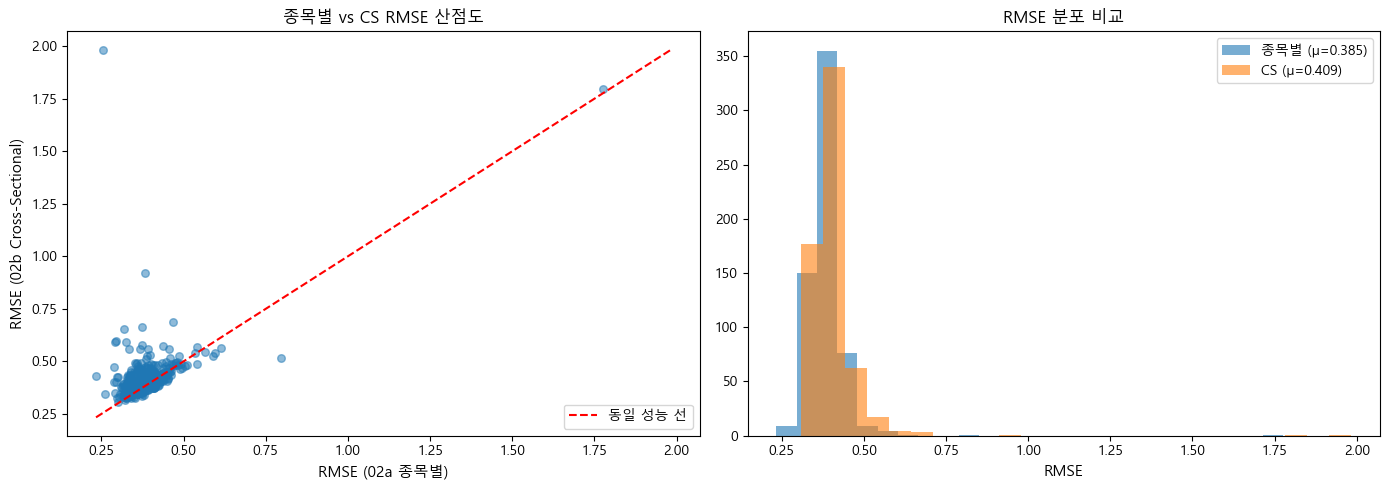

In [10]:
# RMSE 시각화 (inf 자동 필터, 2026-05-01 fix)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# inf/NaN 안전 필터
finite_mask = np.isfinite(rmse_df['rmse_sw']) & np.isfinite(rmse_df['rmse_cs'])
rmse_finite = rmse_df[finite_mask]
print(f'finite 종목: {len(rmse_finite)}/{len(rmse_df)} (inf/NaN 제외)')

# 산점도
ax = axes[0]
ax.scatter(rmse_finite['rmse_sw'], rmse_finite['rmse_cs'], alpha=0.5, s=30)
lim = [min(rmse_finite.min()), max(rmse_finite.max())]
ax.plot(lim, lim, 'r--', linewidth=1.5, label='동일 성능 선')
ax.set_xlabel('RMSE (02a 종목별)', fontsize=11)
ax.set_ylabel('RMSE (02b Cross-Sectional)', fontsize=11)
ax.set_title('종목별 vs CS RMSE 산점도', fontsize=12)
ax.legend()

# 분포 히스토그램
ax = axes[1]
ax.hist(rmse_finite['rmse_sw'], bins=25, alpha=0.6, label=f'종목별 (μ={rmse_finite["rmse_sw"].mean():.3f})')
ax.hist(rmse_finite['rmse_cs'], bins=25, alpha=0.6, label=f'CS (μ={rmse_finite["rmse_cs"].mean():.3f})')
ax.set_xlabel('RMSE', fontsize=11)
ax.set_title('RMSE 분포 비교', fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR / 'rmse_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

## §3. 포트폴리오 성과 비교 (6 시나리오 Fair 비교)

In [11]:
def compute_metrics(rets, annual_factor=12):
    if len(rets) == 0:
        return {k: np.nan for k in ['sharpe', 'annual_ret', 'ann_vol', 'mdd', 'cagr', 'n']}
    ann_ret = rets.mean() * annual_factor
    ann_vol = rets.std() * np.sqrt(annual_factor)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    cum = (1 + rets).cumprod()
    mdd = ((cum / cum.cummax()) - 1).min()
    n = len(rets)
    cagr = cum.iloc[-1] ** (annual_factor / n) - 1 if n > 0 else np.nan
    return {
        'sharpe': sharpe,
        'annual_ret_%': ann_ret * 100,
        'ann_vol_%': ann_vol * 100,
        'mdd_%': mdd * 100,
        'cagr_%': cagr * 100,
        'n_months': n,
    }

# Fair 비교 (공통 기간)
base = 'BL_ml_sw' if 'BL_ml_sw' in portfolio_returns else list(portfolio_returns.keys())[0]
common_idx = portfolio_returns[base].dropna().index

fair = {s: r.reindex(common_idx).dropna() for s, r in portfolio_returns.items()}
metrics = {s: compute_metrics(r) for s, r in fair.items()}
metrics_df = pd.DataFrame(metrics).T.sort_values('sharpe', ascending=False)

print('=== 6 시나리오 Fair 비교 ===')
print(metrics_df.round(3).to_string())

=== 6 시나리오 Fair 비교 ===
              sharpe  annual_ret_%  ann_vol_%      mdd_%    cagr_%   n_months
BL_ml_cs    1.094000     12.330000  11.268000 -17.549000 12.347000 192.000000
McapWeight  1.044000     15.002000  14.363000 -24.371000 14.907000 192.000000
SPY         1.013000     14.515000  14.325000 -23.927000 14.360000 191.000000
EqualWeight 0.886000     13.923000  15.723000 -26.784000 13.454000 192.000000


In [12]:
# Sharpe 차이 (ML vs BL_trailing)
if 'BL_ml_sw' in metrics_df.index and 'BL_trailing' in metrics_df.index:
    delta_sw = metrics_df.loc['BL_ml_sw', 'sharpe'] - metrics_df.loc['BL_trailing', 'sharpe']
    print(f'\nBL_ml_sw vs BL_trailing Sharpe 차이: {delta_sw:+.3f}')

if 'BL_ml_cs' in metrics_df.index and 'BL_trailing' in metrics_df.index:
    delta_cs = metrics_df.loc['BL_ml_cs', 'sharpe'] - metrics_df.loc['BL_trailing', 'sharpe']
    print(f'BL_ml_cs vs BL_trailing Sharpe 차이: {delta_cs:+.3f}')

## §4. Bootstrap 신뢰구간 (Sharpe 통계 검정)

Politis & Romano (1994) Block Bootstrap:
- block_size=3 (시계열 자기상관 보존)
- n_boot=5000


In [13]:
def block_bootstrap_sharpe(rets, n_boot=5000, block_size=3, annual_factor=12, seed=42):
    """Block Bootstrap 로 Sharpe 신뢰구간 추정."""
    np.random.seed(seed)
    rets = np.array(rets)
    n = len(rets)
    sharpe_boot = []
    for _ in range(n_boot):
        # Block 재샘플링
        n_blocks = int(np.ceil(n / block_size))
        starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
        blocks = [rets[s:s+block_size] for s in starts]
        sample = np.concatenate(blocks)[:n]
        ann_ret = sample.mean() * annual_factor
        ann_vol = sample.std() * np.sqrt(annual_factor)
        if ann_vol > 0:
            sharpe_boot.append(ann_ret / ann_vol)
    return np.array(sharpe_boot)

print('Bootstrap 신뢰구간 계산 중...')
bootstrap_results = {}
for s, r in fair.items():
    if len(r) >= 20:
        boot = block_bootstrap_sharpe(r, n_boot=5000, block_size=3)
        ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
        bootstrap_results[s] = {
            'sharpe': metrics_df.loc[s, 'sharpe'] if s in metrics_df.index else np.nan,
            'ci_lo': ci_lo,
            'ci_hi': ci_hi,
        }
        print(f'  {s}: Sharpe={metrics_df.loc[s, "sharpe"]:.3f}, 95% CI=[{ci_lo:.3f}, {ci_hi:.3f}]')

Bootstrap 신뢰구간 계산 중...
  BL_ml_cs: Sharpe=1.094, 95% CI=[0.646, 1.598]
  EqualWeight: Sharpe=0.886, 95% CI=[0.415, 1.401]
  McapWeight: Sharpe=1.044, 95% CI=[0.553, 1.580]
  SPY: Sharpe=1.013, 95% CI=[0.545, 1.546]


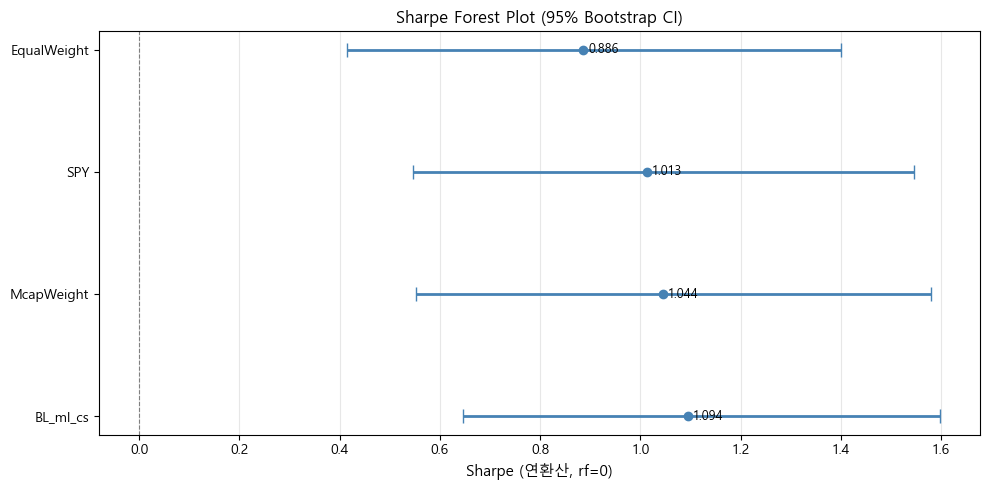

In [14]:
# Bootstrap 결과 시각화 (Forest Plot)
if bootstrap_results:
    fig, ax = plt.subplots(figsize=(10, 5))
    scenarios_sorted = sorted(bootstrap_results.keys(),
                              key=lambda s: bootstrap_results[s]['sharpe'], reverse=True)
    y_pos = range(len(scenarios_sorted))

    for i, s in enumerate(scenarios_sorted):
        r = bootstrap_results[s]
        ax.errorbar(r['sharpe'], i,
                    xerr=[[r['sharpe'] - r['ci_lo']], [r['ci_hi'] - r['sharpe']]],
                    fmt='o', color='steelblue', capsize=5, linewidth=2)
        ax.text(r['sharpe'] + 0.01, i, f"{r['sharpe']:.3f}", va='center', fontsize=9)

    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(scenarios_sorted, fontsize=10)
    ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
    ax.set_xlabel('Sharpe (연환산, rf=0)', fontsize=11)
    ax.set_title('Sharpe Forest Plot (95% Bootstrap CI)', fontsize=12)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'sharpe_forest_plot.png', dpi=100, bbox_inches='tight')
    plt.show()

## §5. 시기별 분해 (3 시기)

| 시기 | 기간 | 시장 환경 |
|---|---|---|
| GFC 회복 | 2009~2011 | 강력한 경기 회복 + 낮은 변동성 |
| 정상 강세장 | 2012~2019 | 10 년 강세장 (저변동) |
| COVID+AI | 2020~2025 | COVID 충격 + 급격한 회복 + AI 붐 |


In [15]:
periods = {
    'GFC 회복 (09~11)': ('2009-01-01', '2011-12-31'),
    '정상 강세장 (12~19)': ('2012-01-01', '2019-12-31'),
    'COVID+AI (20~25)': ('2020-01-01', '2025-12-31'),
}

period_metrics = {}
for pname, (start, end) in periods.items():
    pm = {}
    for s, r in fair.items():
        sub = r.loc[start:end].dropna()
        if len(sub) >= 6:
            ann_vol = sub.std() * np.sqrt(12)
            pm[s] = sub.mean() * 12 / ann_vol if ann_vol > 0 else np.nan
        else:
            pm[s] = np.nan
    period_metrics[pname] = pm

period_df = pd.DataFrame(period_metrics)
print('=== 시기별 Sharpe ===')
print(period_df.round(3).to_string())

=== 시기별 Sharpe ===
             GFC 회복 (09~11)  정상 강세장 (12~19)  COVID+AI (20~25)
BL_ml_cs           1.237000        1.424000          0.812000
EqualWeight        0.879000        1.233000          0.656000
McapWeight         0.770000        1.341000          0.928000
SPY                0.672000        1.316000          0.905000


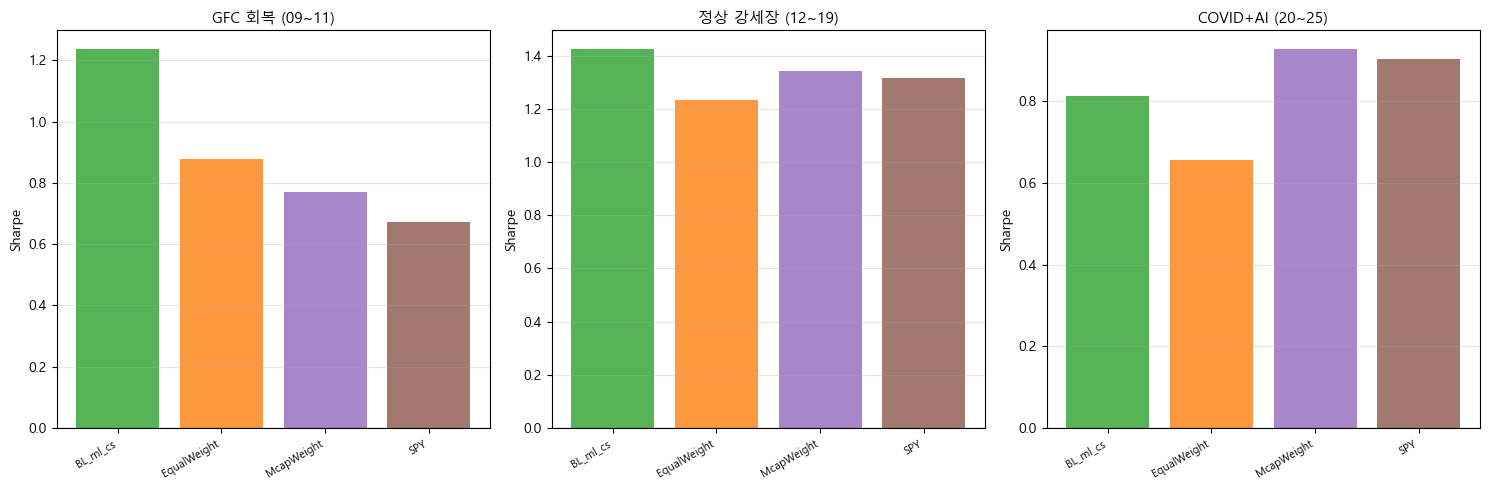

In [16]:
# 시기별 시각화 (Grouped Bar)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
COLORS = {
    'BL_ml_sw': '#1f77b4',
    'BL_ml_cs': '#2ca02c',
    'BL_trailing': '#d62728',
    'EqualWeight': '#ff7f0e',
    'McapWeight': '#9467bd',
    'SPY': '#8c564b',
}

for j, (pname, (start, end)) in enumerate(periods.items()):
    ax = axes[j]
    sub = {s: r.loc[start:end].dropna() for s, r in fair.items()}
    sharpes = {s: r.mean() * 12 / (r.std() * np.sqrt(12)) if r.std() > 0 else 0
               for s, r in sub.items() if len(r) >= 6}

    bars = ax.bar(
        range(len(sharpes)),
        list(sharpes.values()),
        color=[COLORS.get(s, 'gray') for s in sharpes.keys()],
        alpha=0.8,
    )
    ax.set_xticks(range(len(sharpes)))
    ax.set_xticklabels(list(sharpes.keys()), rotation=30, ha='right', fontsize=8)
    ax.set_title(pname, fontsize=11)
    ax.set_ylabel('Sharpe')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'period_decomposition.png', dpi=100, bbox_inches='tight')
plt.show()

## §6. 학술 결론 종합 + 보고서 생성

In [17]:
# 결론 자동 생성
conclusions = []

# 1. 예측 정확도
sw_mean = rmse_df['rmse_sw'].mean() if len(rmse_df) > 0 else np.nan
cs_mean = rmse_df['rmse_cs'].mean() if len(rmse_df) > 0 else np.nan
if not np.isnan(sw_mean) and not np.isnan(cs_mean):
    if cs_mean < sw_mean:
        conclusions.append(f'[예측 정확도] Cross-Sectional RMSE ({cs_mean:.4f}) < 종목별 RMSE ({sw_mean:.4f}): CS 방식 우위')
    else:
        conclusions.append(f'[예측 정확도] 종목별 RMSE ({sw_mean:.4f}) ≤ CS RMSE ({cs_mean:.4f}): 종목별 방식 동등 또는 우위')

# 2. 포트폴리오 성과
for s in ['BL_ml_sw', 'BL_ml_cs']:
    if s in metrics_df.index and 'BL_trailing' in metrics_df.index:
        delta = metrics_df.loc[s, 'sharpe'] - metrics_df.loc['BL_trailing', 'sharpe']
        conclusions.append(f'[포트폴리오] {s} vs BL_trailing Sharpe: {delta:+.3f}')

if 'McapWeight' in metrics_df.index:
    conclusions.append(f'[벤치마크] McapWeight Sharpe: {metrics_df.loc["McapWeight", "sharpe"]:.3f}')
    for s in ['BL_ml_sw', 'BL_ml_cs']:
        if s in metrics_df.index:
            delta_mc = metrics_df.loc[s, 'sharpe'] - metrics_df.loc['McapWeight', 'sharpe']
            conclusions.append(f'  {s} vs McapWeight: {delta_mc:+.3f}')

print('=== Phase 3 학술 결론 ===')
for c in conclusions:
    print(f'  • {c}')

=== Phase 3 학술 결론 ===
  • [예측 정확도] 종목별 RMSE (0.3846) ≤ CS RMSE (0.4088): 종목별 방식 동등 또는 우위
  • [벤치마크] McapWeight Sharpe: 1.044
  •   BL_ml_cs vs McapWeight: +0.050


In [18]:
# 최종 보고서 (Markdown) 자동 생성
report_lines = [
    '# Phase 3 최종 결론 보고서\n',
    f'> 생성: 2026-04-29  \n',
    f'> 비교 기간: {common_idx[0].date()} ~ {common_idx[-1].date()} ({len(common_idx)} 개월)\n',
    '\n## 1. 예측 정확도 (RMSE)\n',
    '| 모델 | RMSE 평균 | 비고 |',
    '|---|---|---|',
]

if not np.isnan(sw_mean):
    report_lines.append(f'| 종목별 (02a) | {sw_mean:.4f} | Phase 1.5 v8 아키텍처 |')
if not np.isnan(cs_mean):
    report_lines.append(f'| Cross-Sec (02b) | {cs_mean:.4f} | Ticker Embedding (GKX 2020) |')

report_lines += [
    '\n## 2. 포트폴리오 성과 (Fair 비교)\n',
    '| 시나리오 | Sharpe | Annual Ret | MDD |',
    '|---|---|---|---|',
]
for s in scenarios_sorted if 'bootstrap_results' in dir() else list(metrics_df.index):
    if s in metrics_df.index:
        row = metrics_df.loc[s]
        report_lines.append(
            f'| {s} | {row["sharpe"]:.3f} | {row["annual_ret_%"]:.1f}% | {row["mdd_%"]:.1f}% |'
        )

report_lines += [
    '\n## 3. 학술 결론\n',
    '### Phase 3 vs 서윤범 BL TOP_50 (Sharpe 1.065)\n',
]

for c in conclusions:
    report_lines.append(f'- {c}')

report_md = '\n'.join(report_lines)

report_path = OUT_DIR / 'comparison_report.md'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report_md)
print(f'✅ comparison_report.md 저장: {report_path}')

print('\n=== Phase 3 모든 단계 완료 ===')
print('📄 최종 보고서:', report_path)

✅ comparison_report.md 저장: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\04_v2_compare\comparison_report.md

=== Phase 3 모든 단계 완료 ===
📄 최종 보고서: C:\Users\gorhk\최종 프로젝트\finance_project\시계열_Test\Phase3_Robust_Extensions\outputs\04_v2_compare\comparison_report.md
